In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir('/home/code0053/news-sentiment-analysis')
plt.style.use('seaborn-v0_8')

print("Libraries loaded!")
print("Working directory:", os.getcwd())

Libraries loaded!
Working directory: /home/code0053/news-sentiment-analysis


In [2]:
# Cell 2: Load Stock Price Data
import glob

# Load all CSV files from Data folder
stock_files = glob.glob('data/raw/Data/*.csv')
print("Stock files found:", stock_files)

# Load each stock into a dictionary
stocks = {}
for f in stock_files:
    ticker = os.path.basename(f).replace('.csv', '')
    df = pd.read_csv(f)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    stocks[ticker] = df
    print(f"{ticker}: {df.shape} | Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# Preview one stock
print("\n=== AAPL Sample ===")
print(stocks['AAPL'].head())

Stock files found: ['data/raw/Data/AMZN.csv', 'data/raw/Data/NVDA.csv', 'data/raw/Data/AAPL.csv', 'data/raw/Data/META.csv', 'data/raw/Data/GOOG.csv']
AMZN: (3774, 6) | Date range: 2009-01-02 to 2023-12-29
NVDA: (3774, 6) | Date range: 2009-01-02 to 2023-12-29
AAPL: (3774, 6) | Date range: 2009-01-02 to 2023-12-29
META: (2923, 6) | Date range: 2012-05-18 to 2023-12-29
GOOG: (3774, 6) | Date range: 2009-01-02 to 2023-12-29

=== AAPL Sample ===
        Date     Close      High       Low      Open      Volume
0 2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1 2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2 2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3 2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4 2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [3]:
# Cell 3: Check Data Quality
for ticker, df in stocks.items():
    print(f"\n=== {ticker} ===")
    print(f"Missing values:\n{df.isnull().sum()}")
    print(f"Columns: {df.columns.tolist()}")


=== AMZN ===
Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

=== NVDA ===
Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

=== AAPL ===
Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

=== META ===
Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

=== GOOG ===
Missing values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [4]:
# Cell 4: Compute Technical Indicators for all stocks
def compute_indicators(df):
    # --- Moving Averages ---
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

    # --- RSI ---
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # --- MACD ---
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    # --- Daily Returns ---
    df['Daily_Return'] = df['Close'].pct_change() * 100

    return df

# Apply to all stocks
for ticker in stocks:
    stocks[ticker] = compute_indicators(stocks[ticker])
    print(f" {ticker} indicators computed")

print("\nAll indicators computed!")

 AMZN indicators computed
 NVDA indicators computed
 AAPL indicators computed
 META indicators computed
 GOOG indicators computed

All indicators computed!


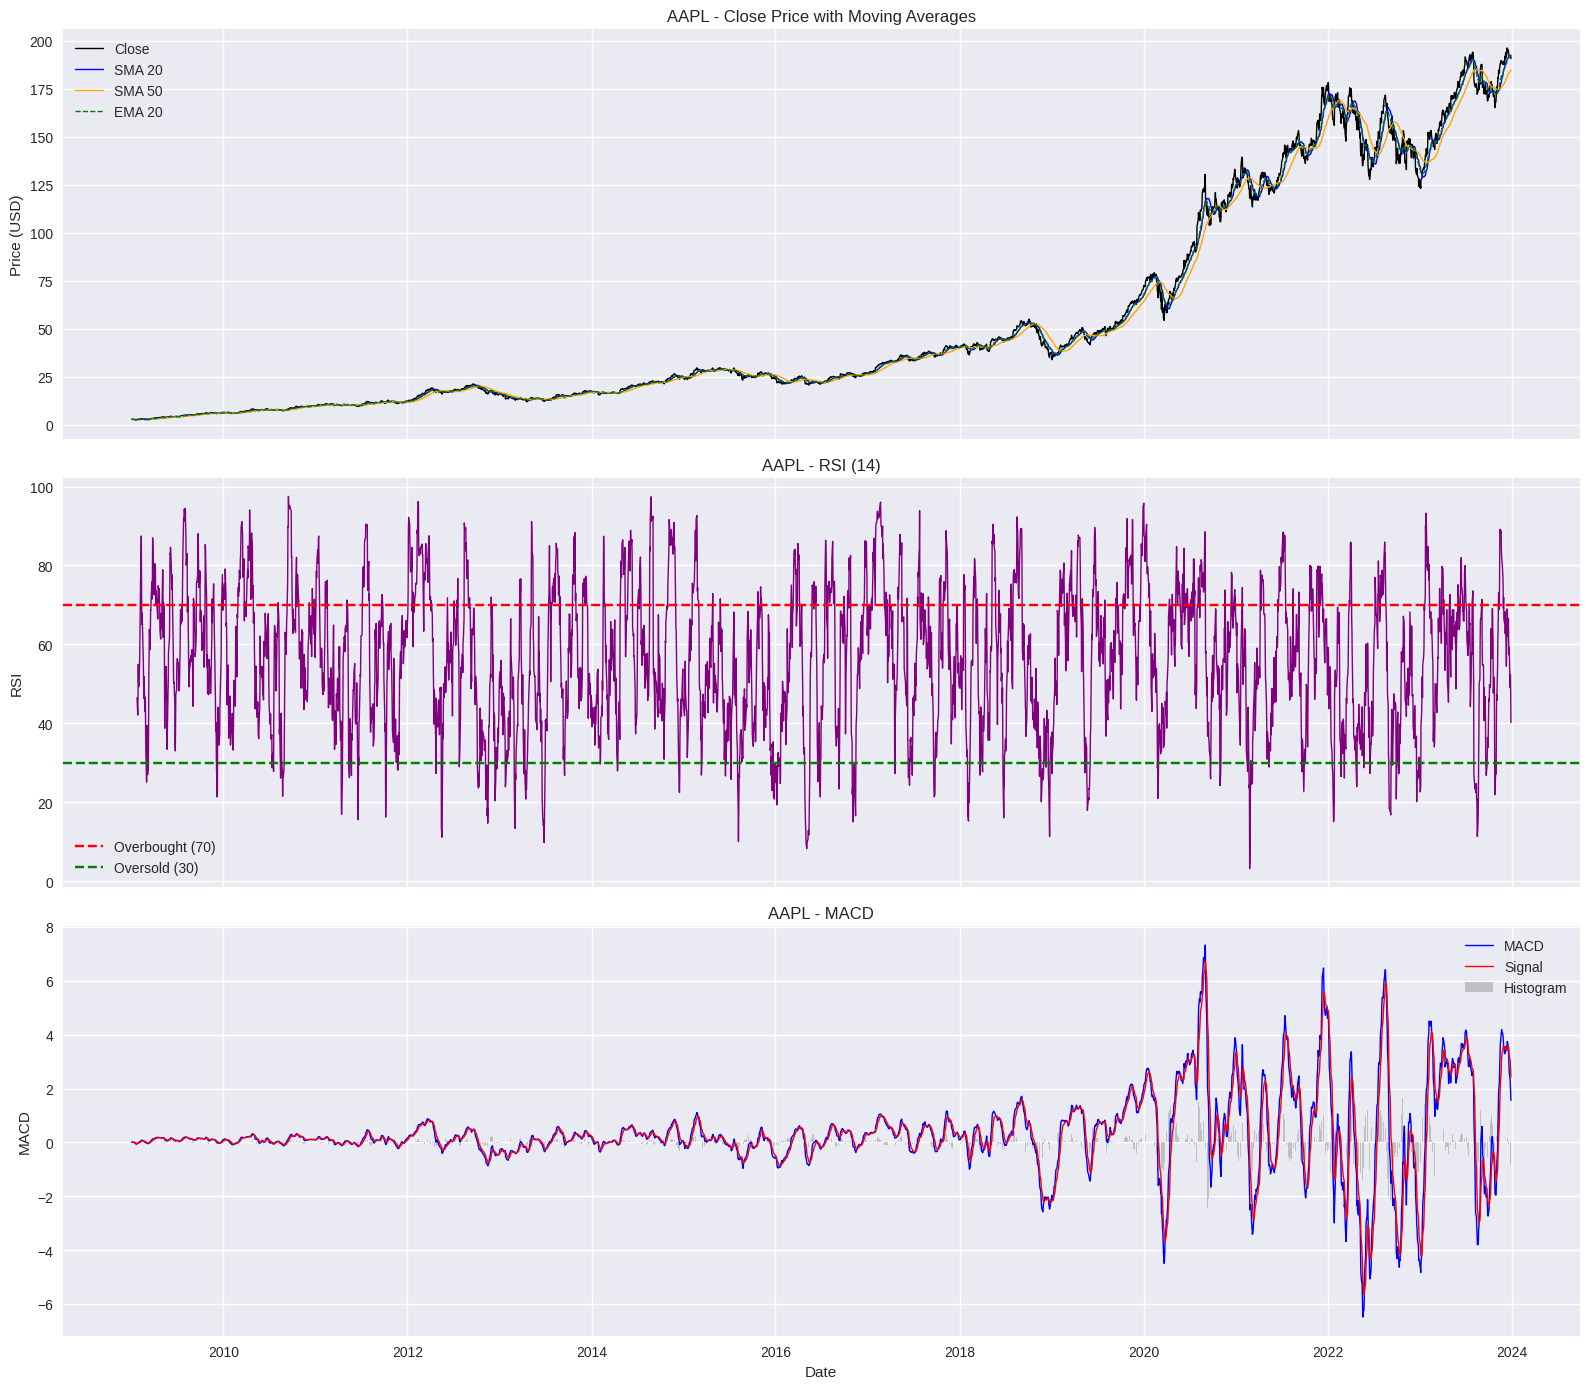

AAPL chart saved!


In [6]:
# Cell 5: Visualize AAPL - Price + Moving Averages + RSI + MACD
ticker = 'AAPL'
df = stocks[ticker].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# Plot 1: Price + Moving Averages
axes[0].plot(df['Date'], df['Close'], label='Close', color='black', linewidth=1)
axes[0].plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1)
axes[0].plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1)
axes[0].plot(df['Date'], df['EMA_20'], label='EMA 20', color='green', linewidth=1, linestyle='--')
axes[0].set_title(f'{ticker} - Close Price with Moving Averages')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Plot 2: RSI
axes[1].plot(df['Date'], df['RSI'], color='purple', linewidth=1)
axes[1].axhline(70, color='red', linestyle='--', label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[1].set_title(f'{ticker} - RSI (14)')
axes[1].set_ylabel('RSI')
axes[1].legend()

# Plot 3: MACD
axes[2].plot(df['Date'], df['MACD'], label='MACD', color='blue', linewidth=1)
axes[2].plot(df['Date'], df['MACD_Signal'], label='Signal', color='red', linewidth=1)
axes[2].bar(df['Date'], df['MACD_Hist'], label='Histogram', color='gray', alpha=0.4)
axes[2].set_title(f'{ticker} - MACD')
axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'notebooks/{ticker}_technical_analysis.png', dpi=150)
plt.show()
print(f"{ticker} chart saved!")

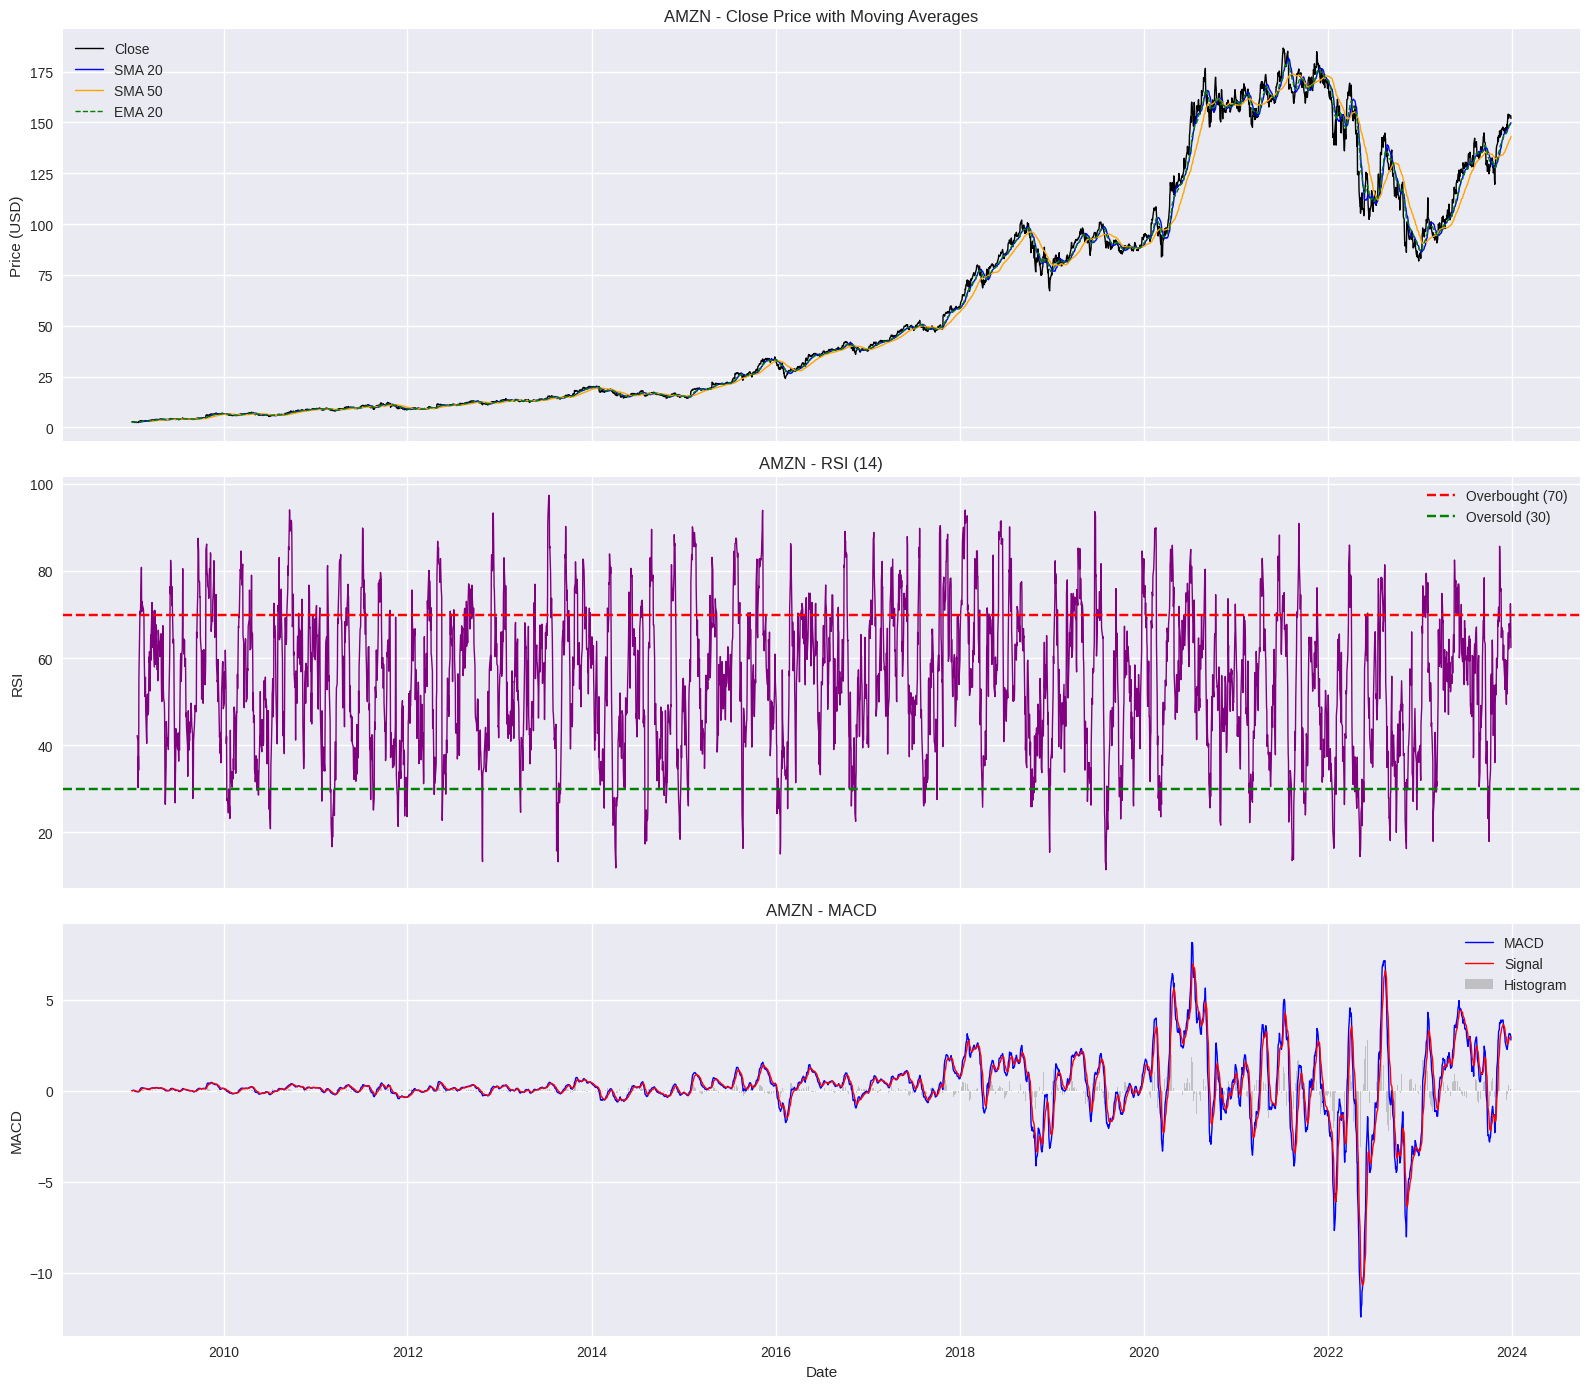

 AMZN chart saved!


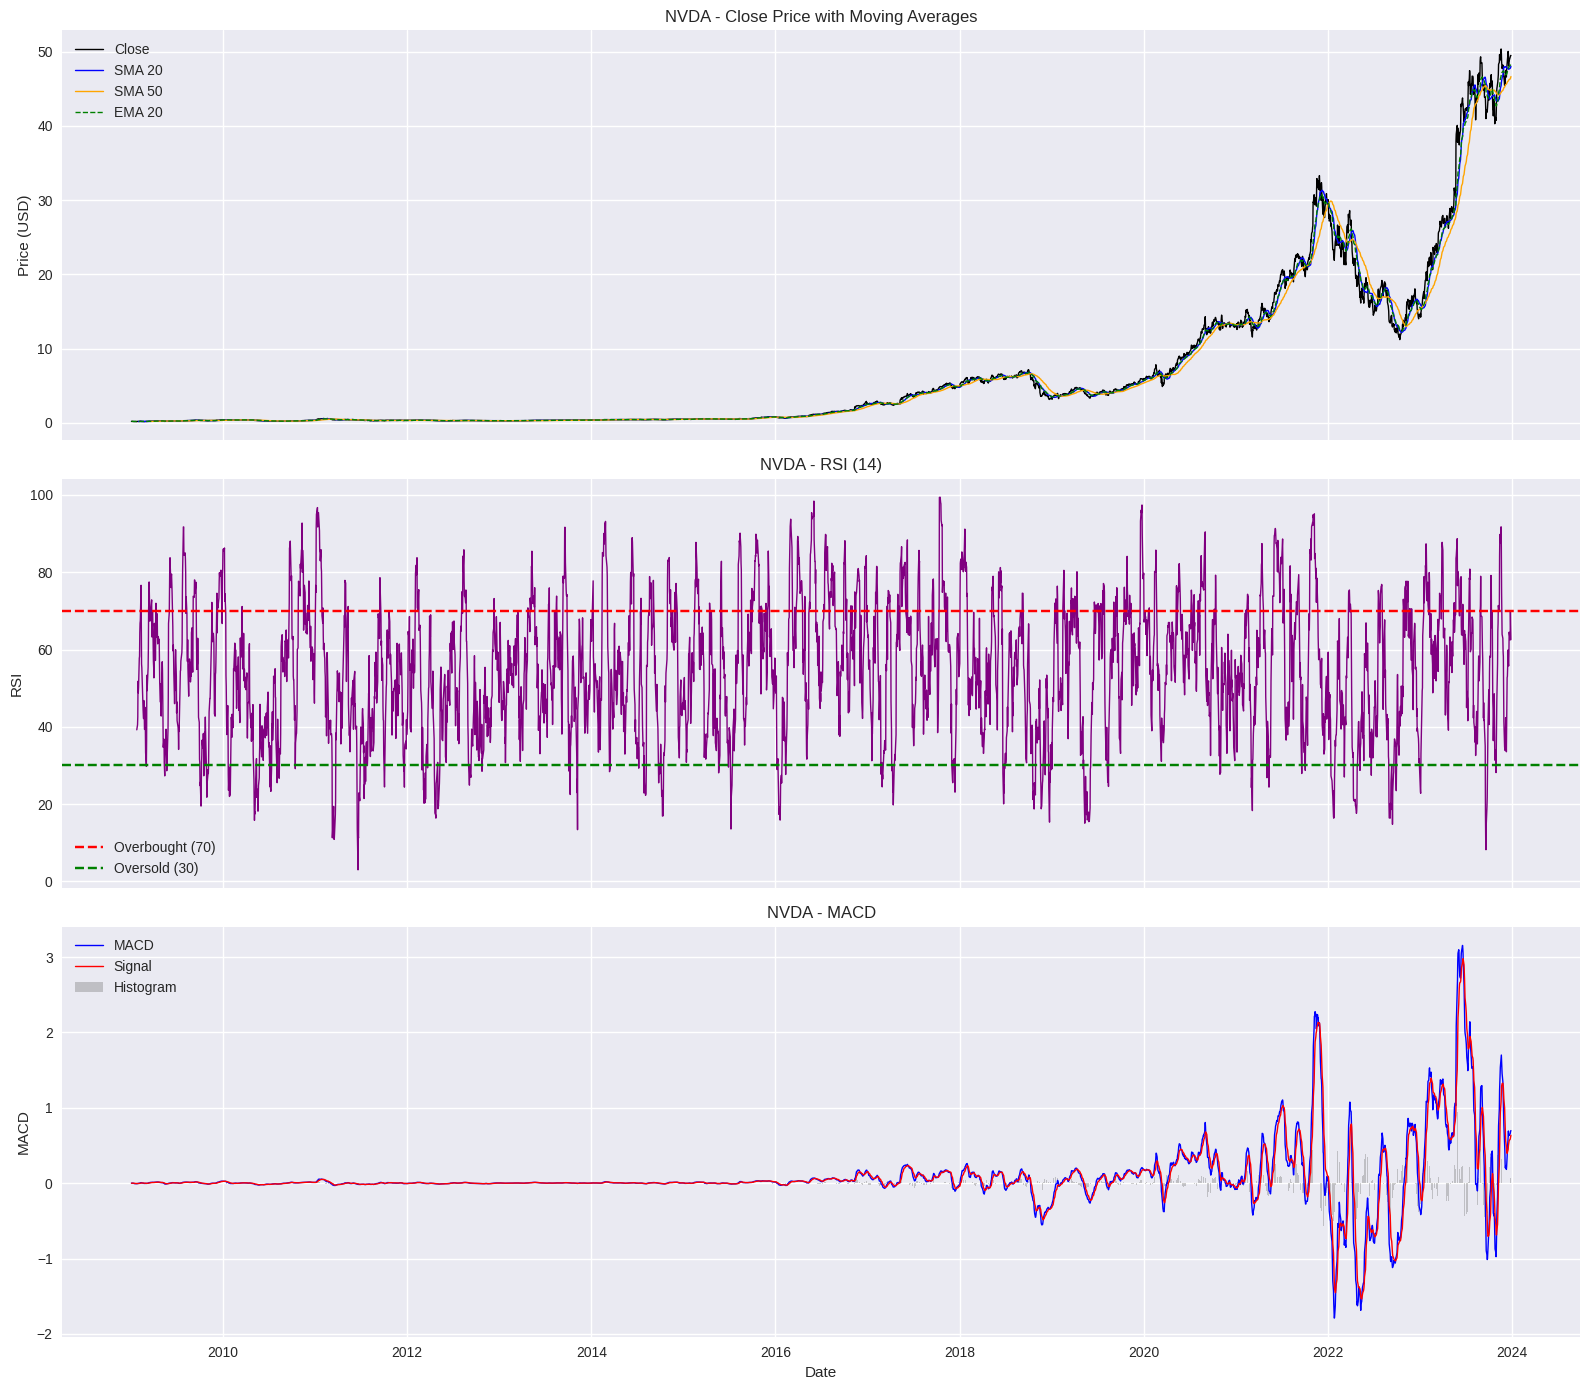

 NVDA chart saved!


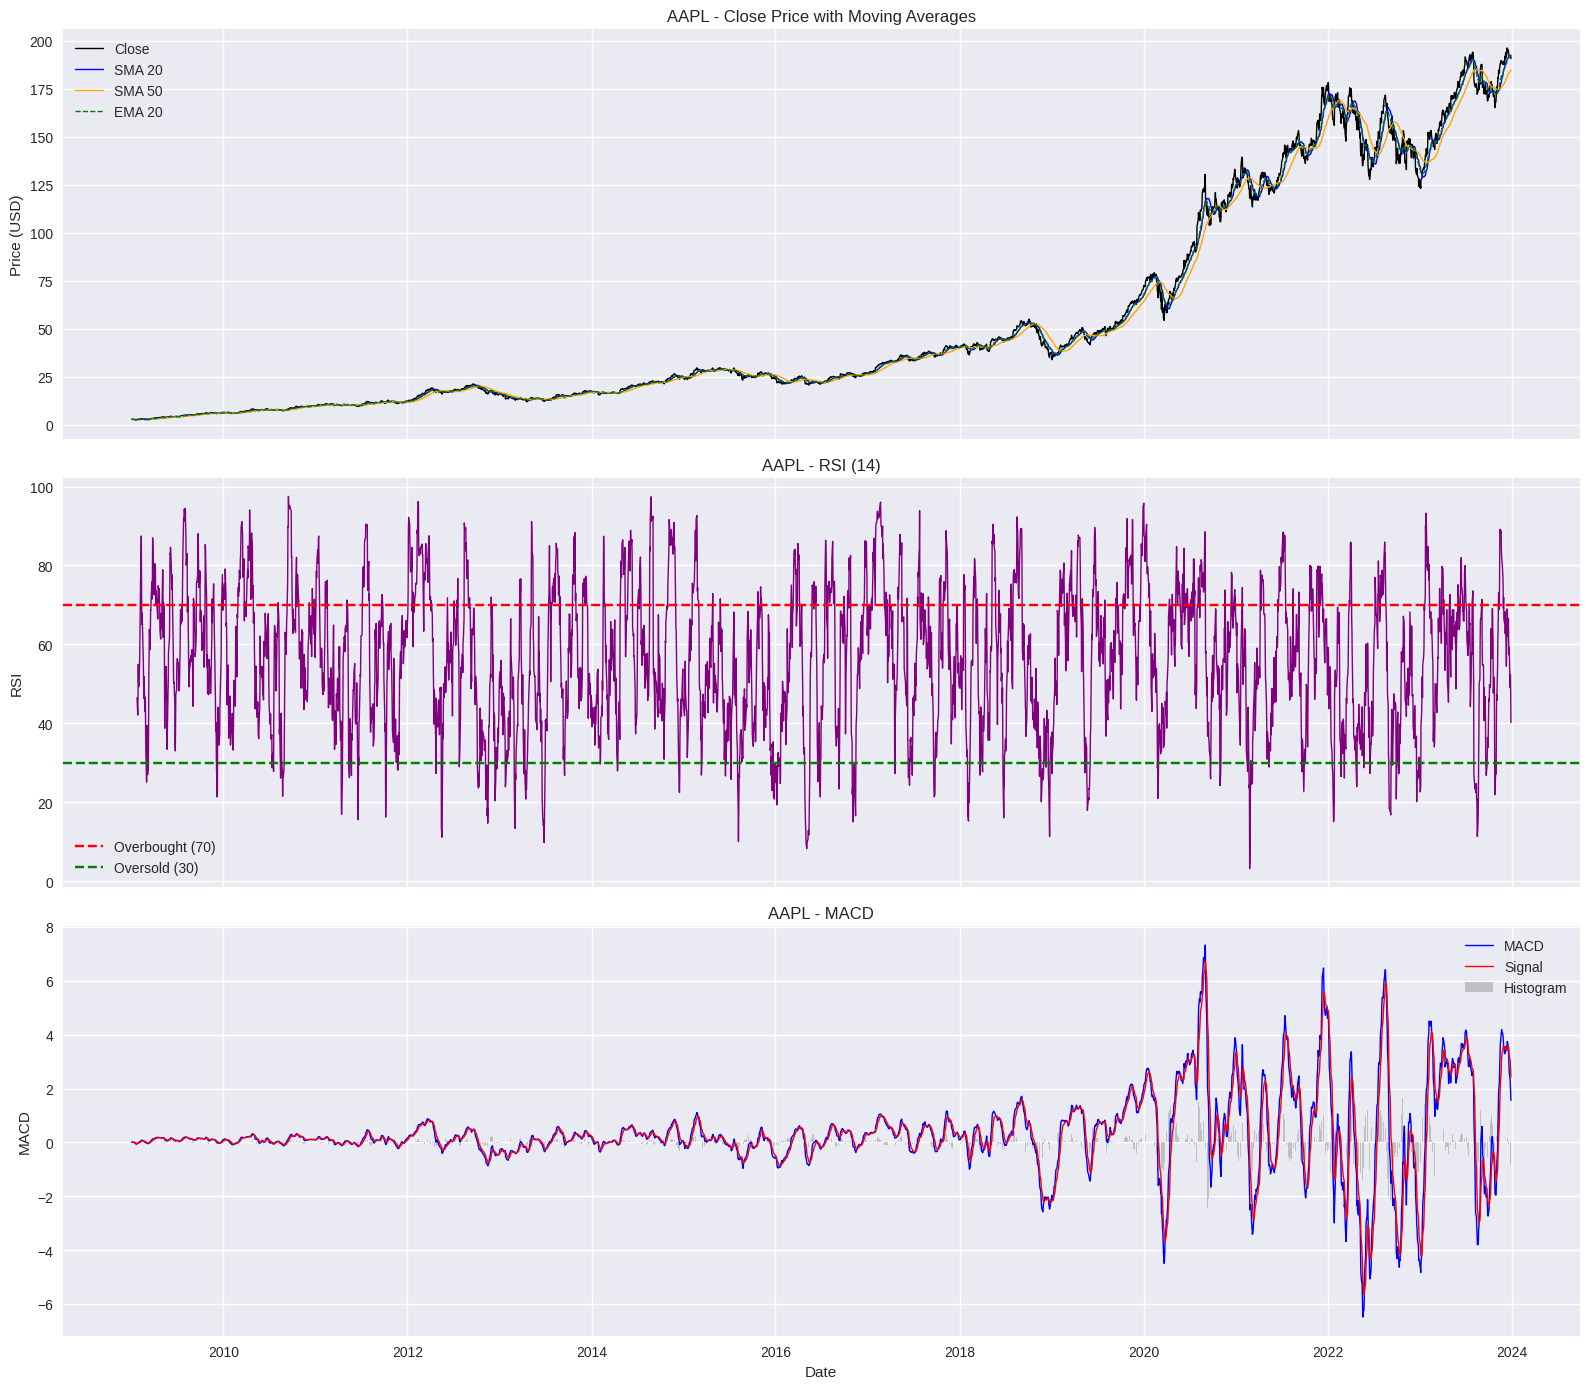

 AAPL chart saved!


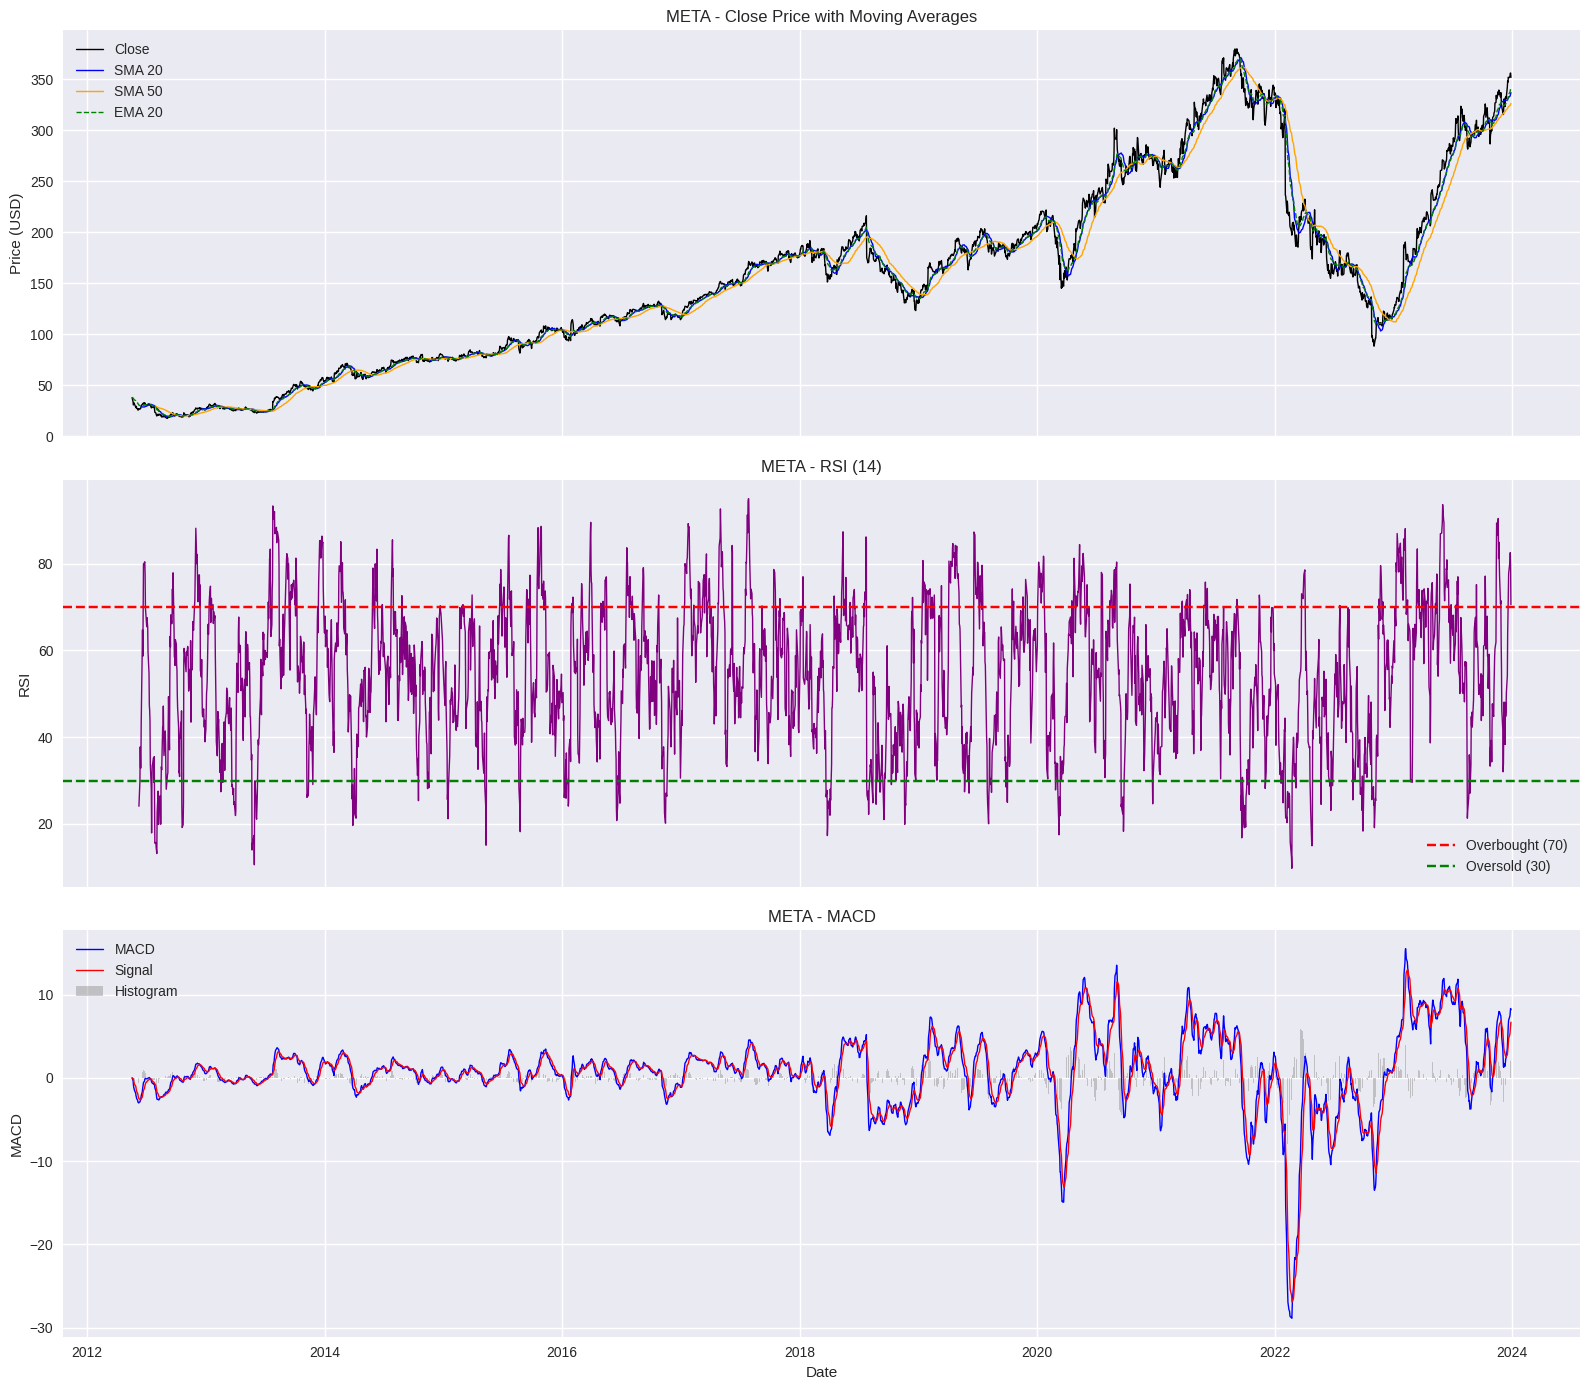

 META chart saved!


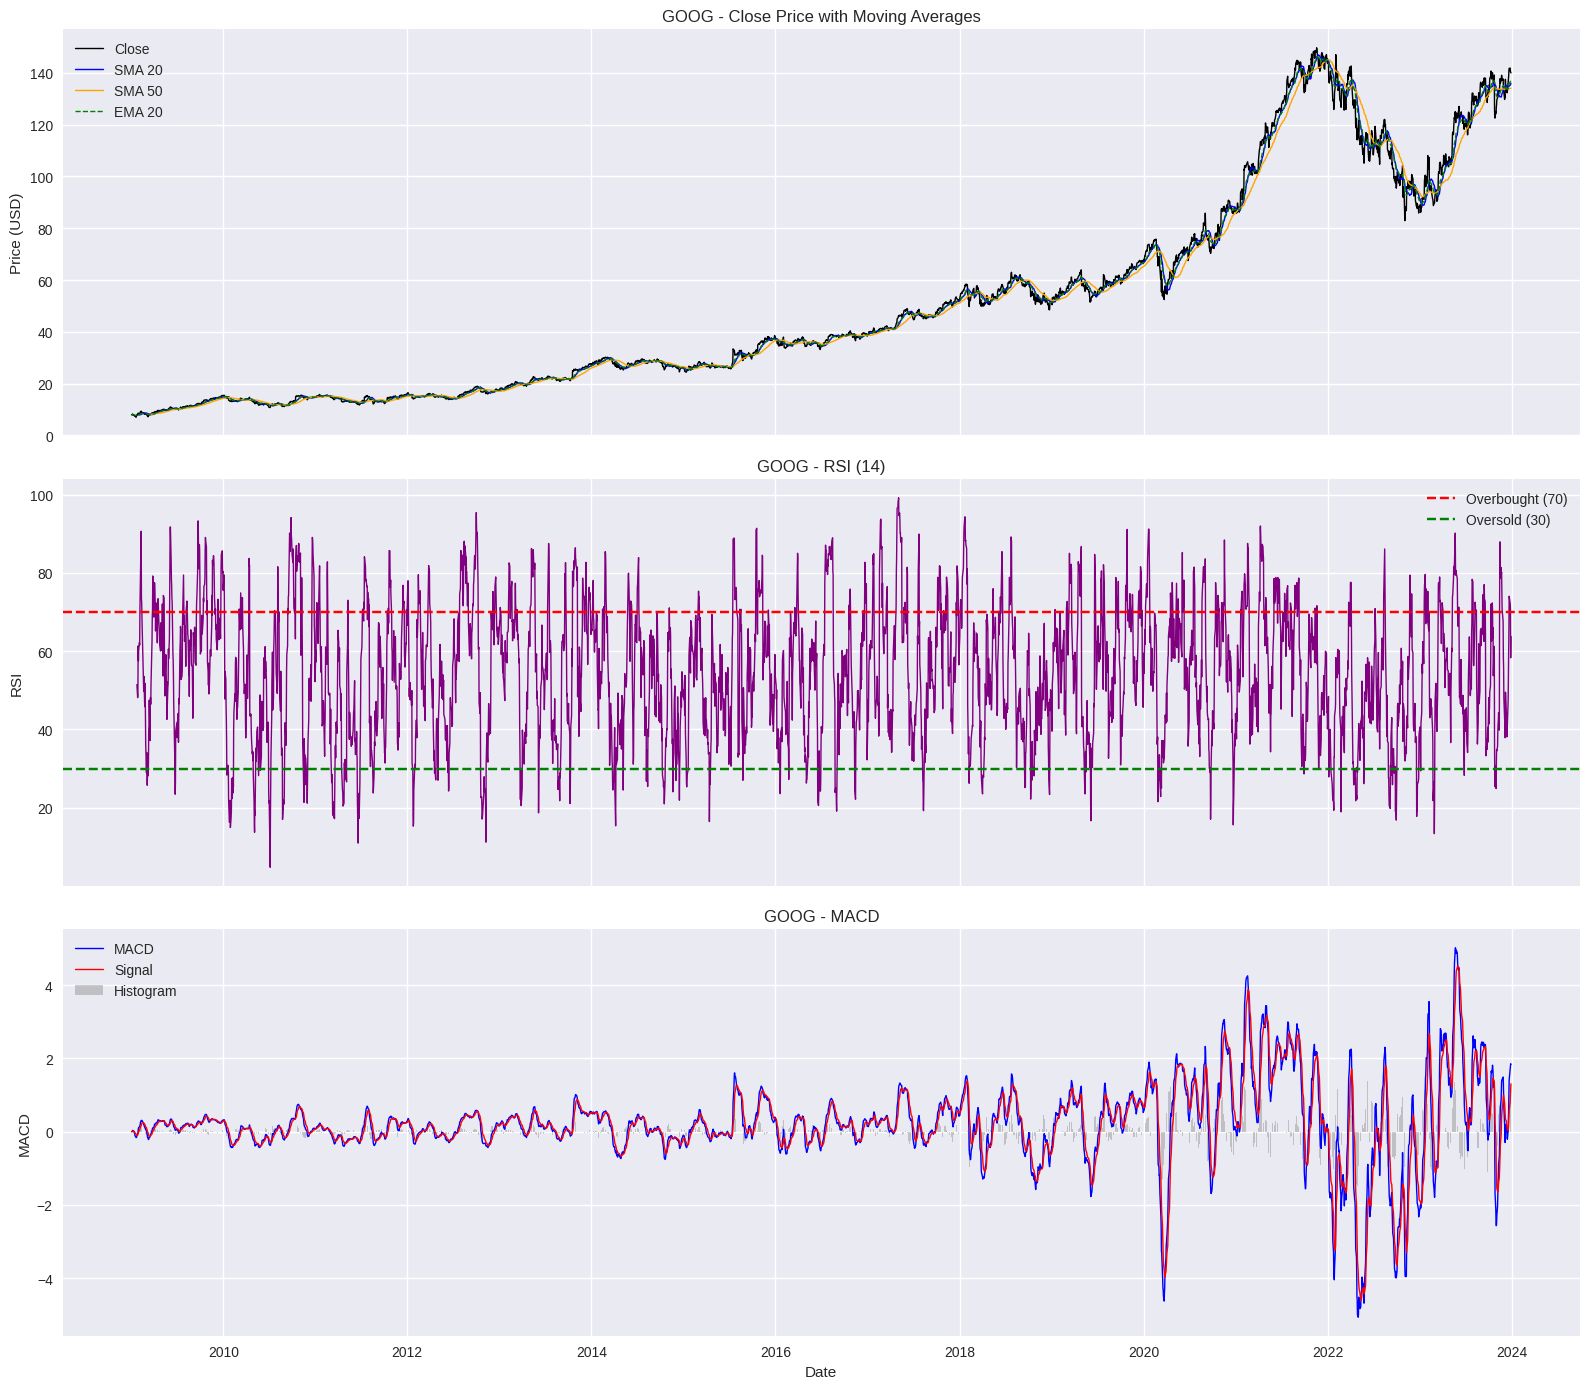

 GOOG chart saved!


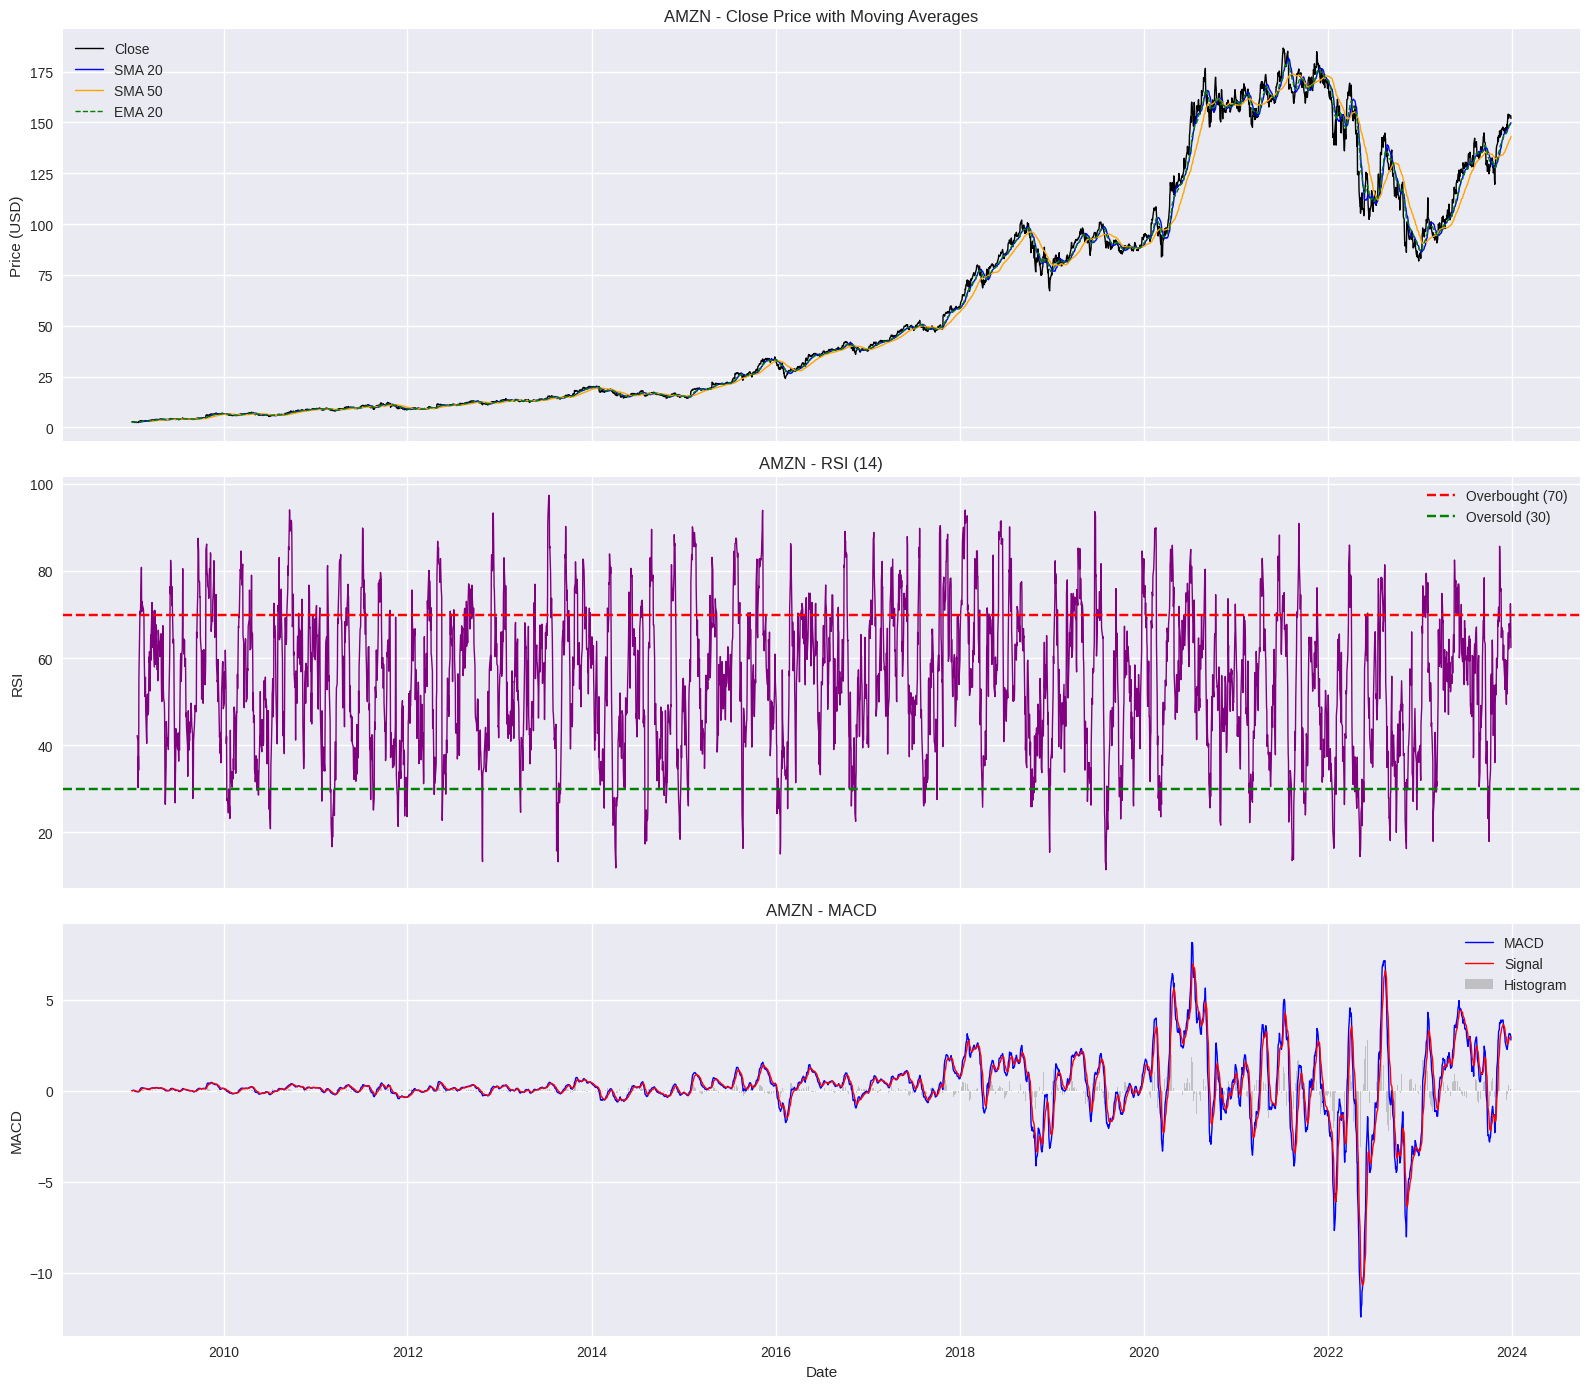

 AMZN chart saved!


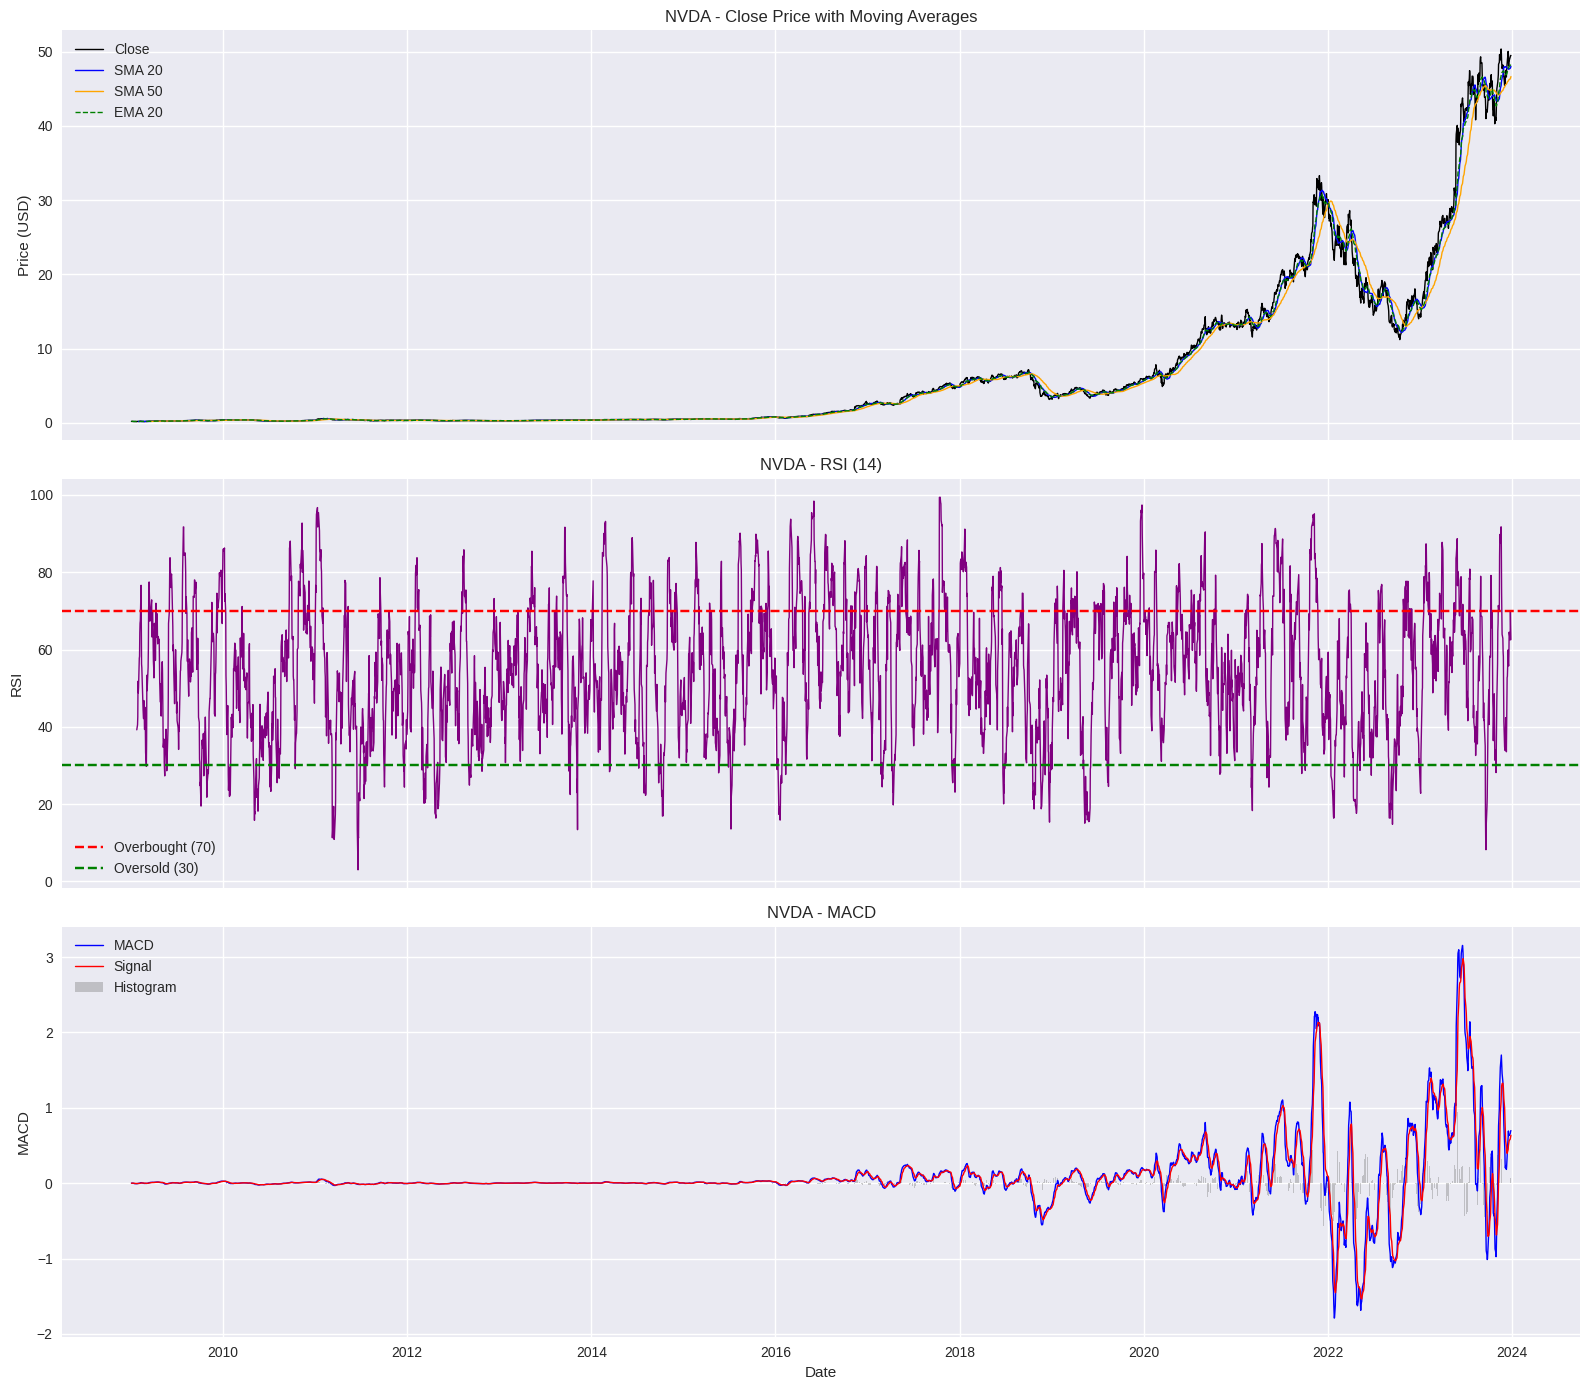

 NVDA chart saved!


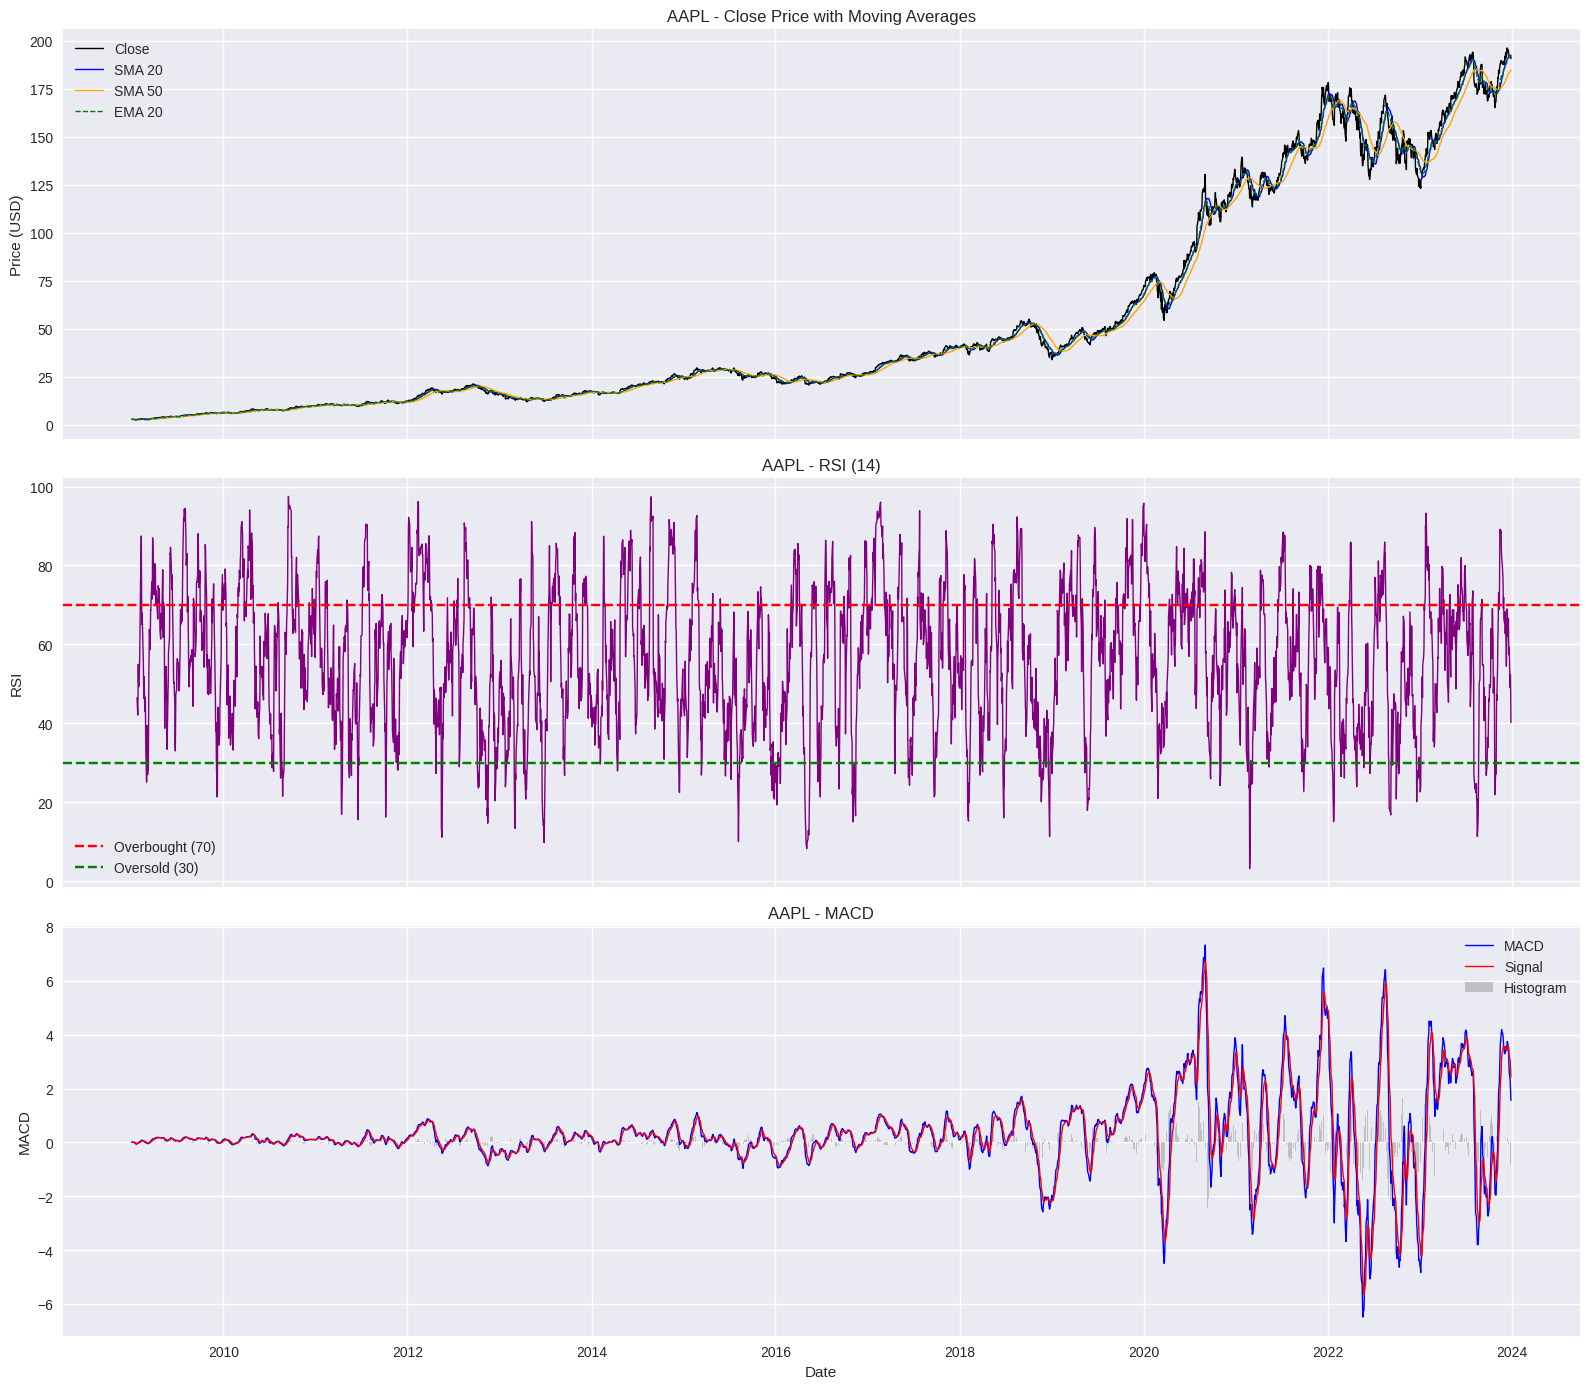

 AAPL chart saved!


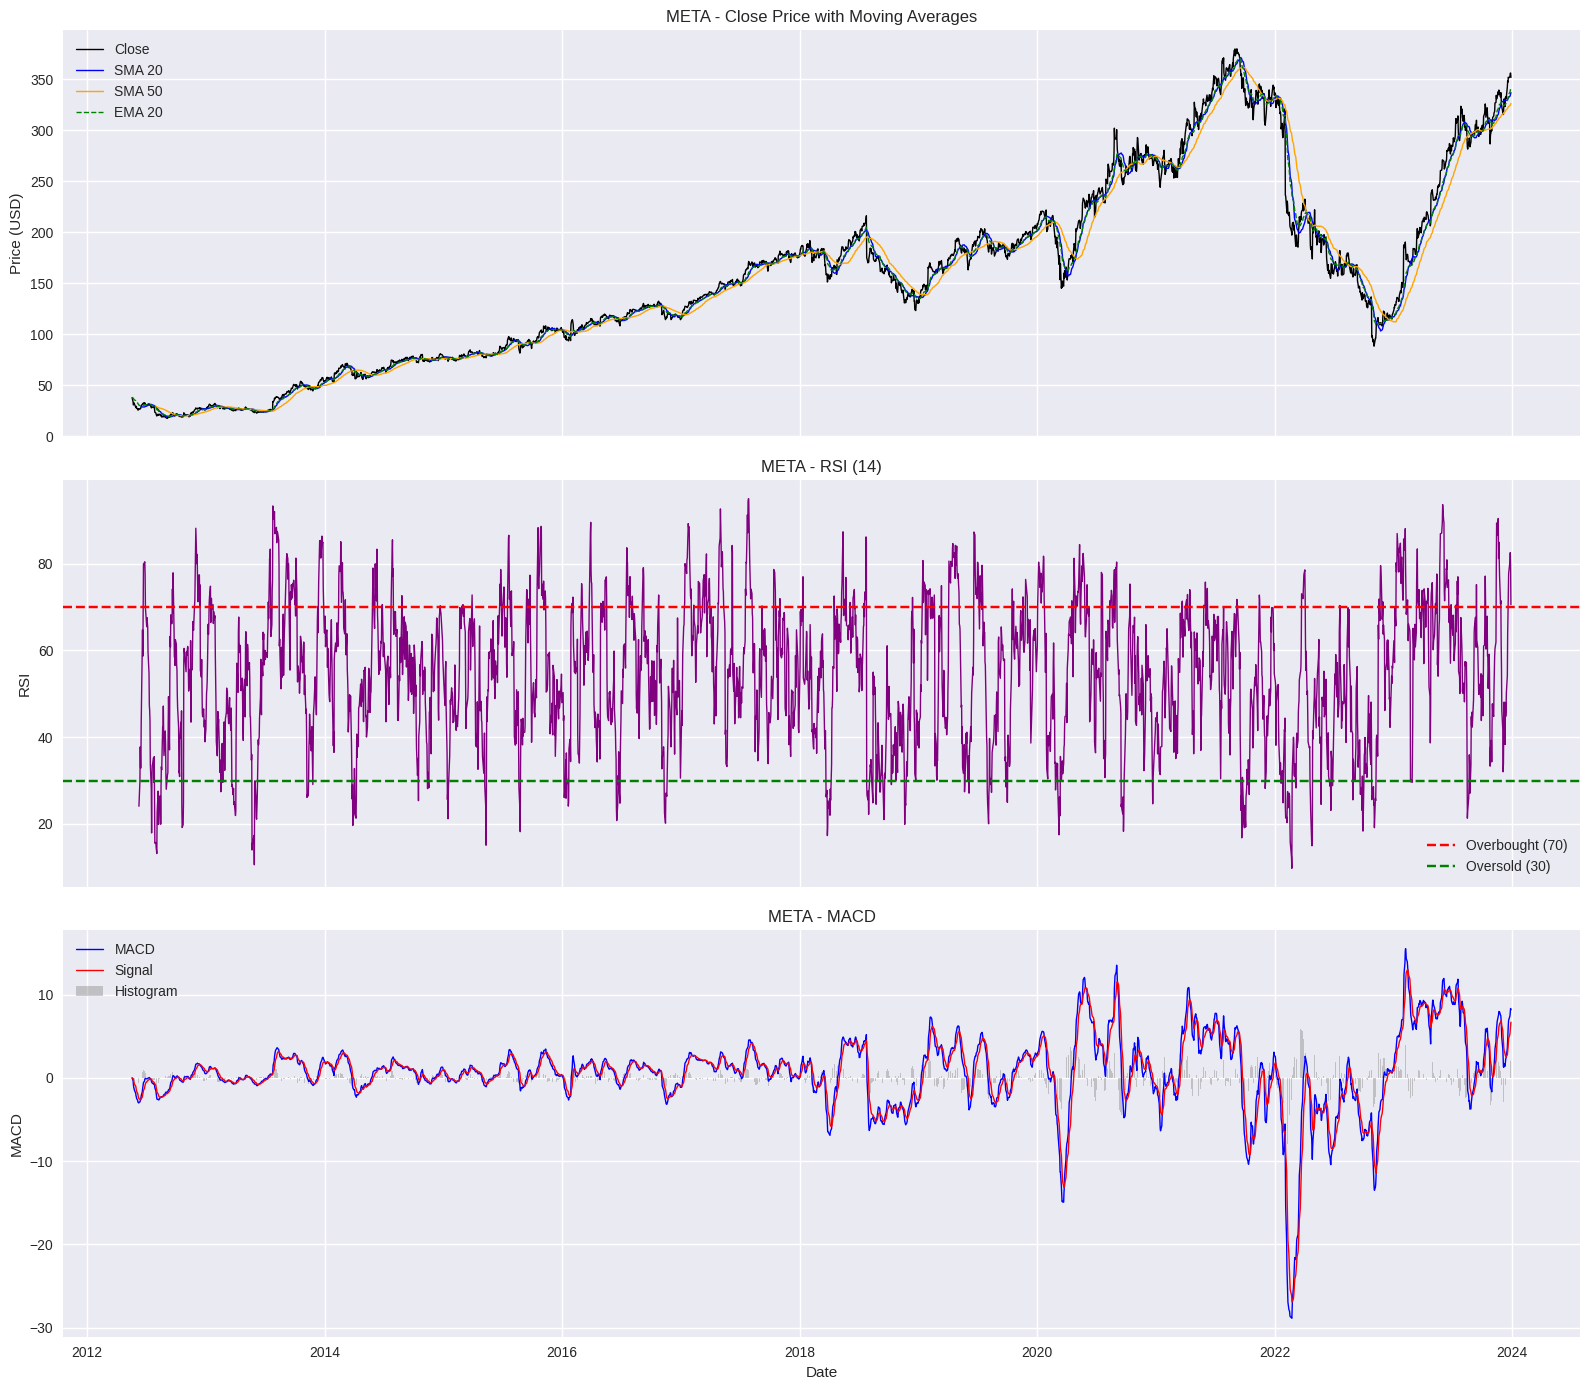

 META chart saved!


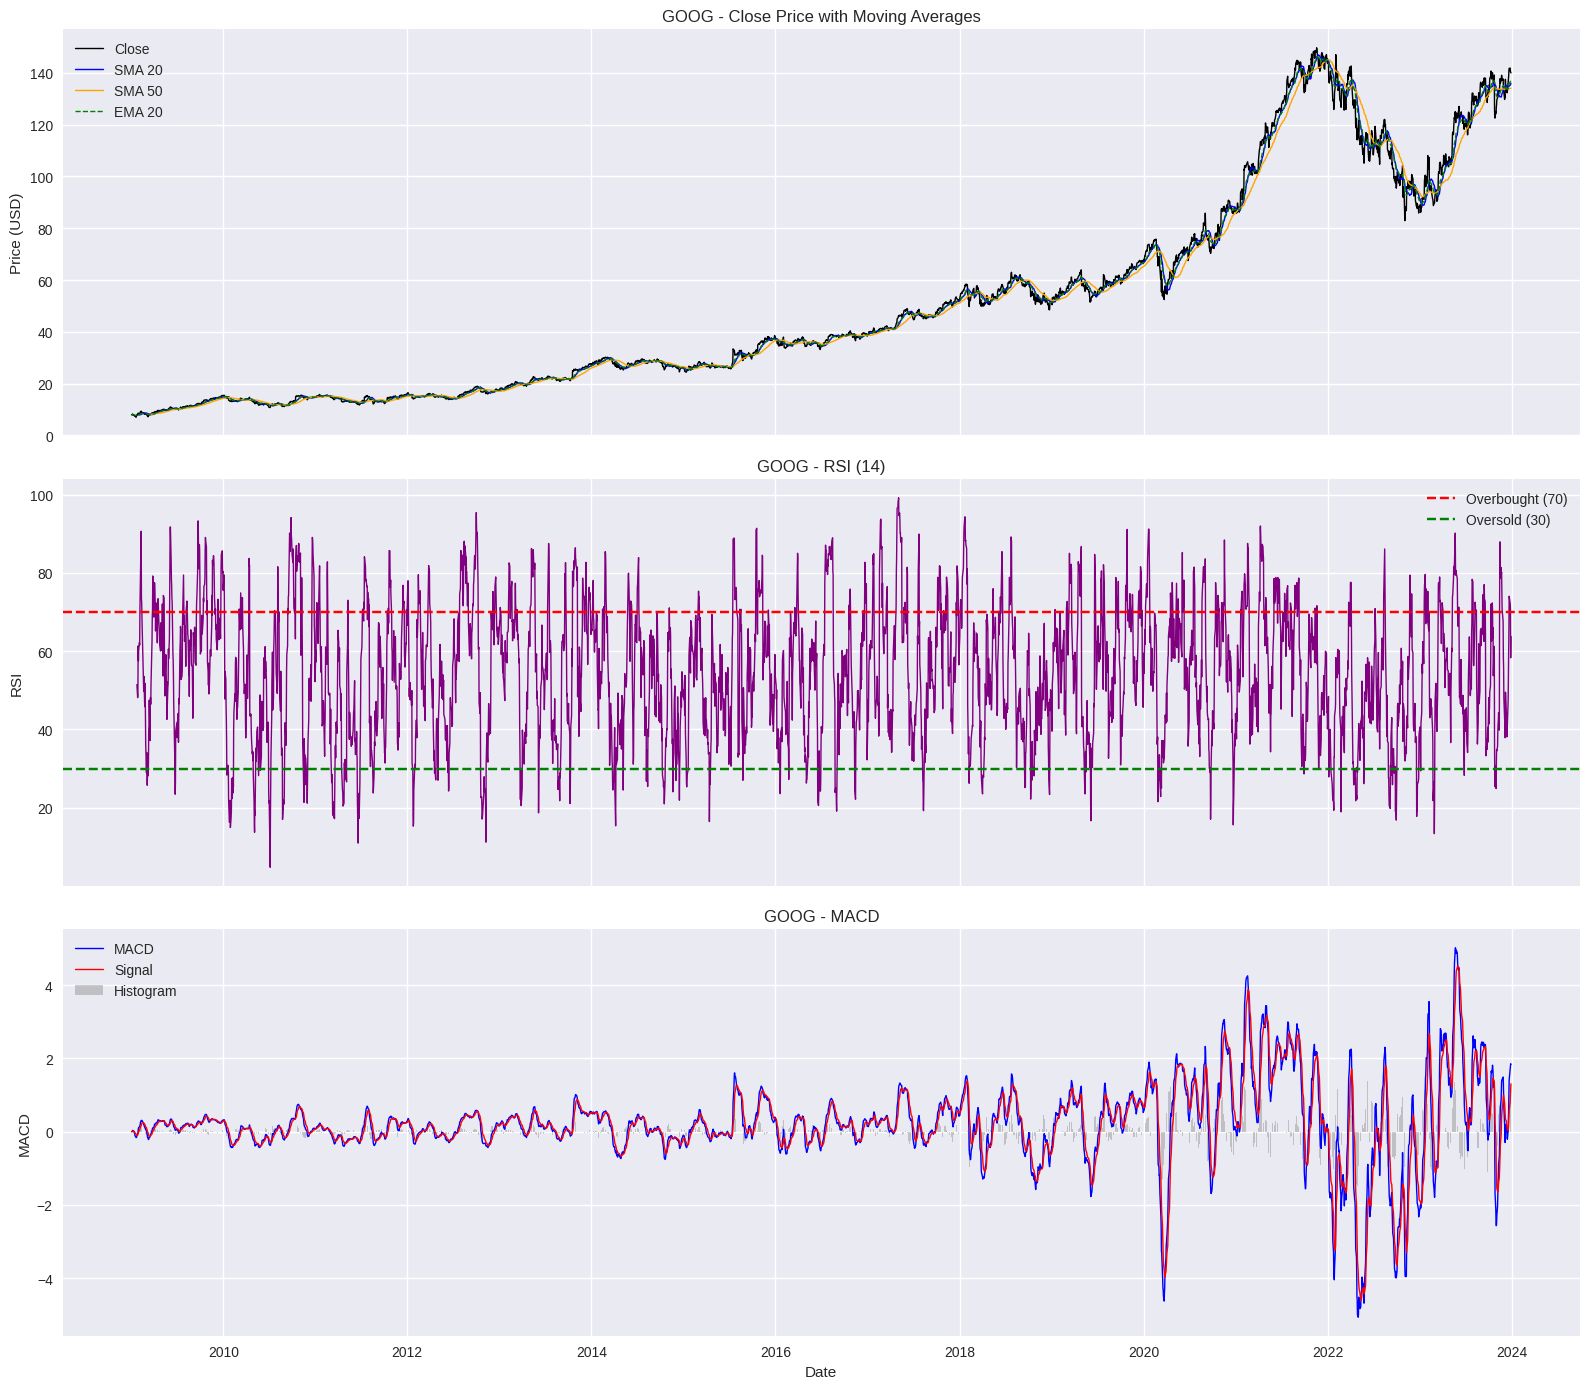

 GOOG chart saved!


In [7]:
# Cell 6: Plot all stocks
for ticker in stocks:
    df = stocks[ticker].copy()

    fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

    # Plot 1: Price + Moving Averages
    axes[0].plot(df['Date'], df['Close'], label='Close', color='black', linewidth=1)
    axes[0].plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1)
    axes[0].plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1)
    axes[0].plot(df['Date'], df['EMA_20'], label='EMA 20', color='green', linewidth=1, linestyle='--')
    axes[0].set_title(f'{ticker} - Close Price with Moving Averages')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()

    # Plot 2: RSI
    axes[1].plot(df['Date'], df['RSI'], color='purple', linewidth=1)
    axes[1].axhline(70, color='red', linestyle='--', label='Overbought (70)')
    axes[1].axhline(30, color='green', linestyle='--', label='Oversold (30)')
    axes[1].set_title(f'{ticker} - RSI (14)')
    axes[1].set_ylabel('RSI')
    axes[1].legend()

    # Plot 3: MACD
    axes[2].plot(df['Date'], df['MACD'], label='MACD', color='blue', linewidth=1)
    axes[2].plot(df['Date'], df['MACD_Signal'], label='Signal', color='red', linewidth=1)
    axes[2].bar(df['Date'], df['MACD_Hist'], label='Histogram', color='gray', alpha=0.4)
    axes[2].set_title(f'{ticker} - MACD')
    axes[2].set_ylabel('MACD')
    axes[2].set_xlabel('Date')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f'notebooks/{ticker}_technical_analysis.png', dpi=150)
    plt.show()
    print(f" {ticker} chart saved!")# Cell 6: Plot all stocks
for ticker in stocks:
    df = stocks[ticker].copy()

    fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

    # Plot 1: Price + Moving Averages
    axes[0].plot(df['Date'], df['Close'], label='Close', color='black', linewidth=1)
    axes[0].plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1)
    axes[0].plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1)
    axes[0].plot(df['Date'], df['EMA_20'], label='EMA 20', color='green', linewidth=1, linestyle='--')
    axes[0].set_title(f'{ticker} - Close Price with Moving Averages')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()

    # Plot 2: RSI
    axes[1].plot(df['Date'], df['RSI'], color='purple', linewidth=1)
    axes[1].axhline(70, color='red', linestyle='--', label='Overbought (70)')
    axes[1].axhline(30, color='green', linestyle='--', label='Oversold (30)')
    axes[1].set_title(f'{ticker} - RSI (14)')
    axes[1].set_ylabel('RSI')
    axes[1].legend()

    # Plot 3: MACD
    axes[2].plot(df['Date'], df['MACD'], label='MACD', color='blue', linewidth=1)
    axes[2].plot(df['Date'], df['MACD_Signal'], label='Signal', color='red', linewidth=1)
    axes[2].bar(df['Date'], df['MACD_Hist'], label='Histogram', color='gray', alpha=0.4)
    axes[2].set_title(f'{ticker} - MACD')
    axes[2].set_ylabel('MACD')
    axes[2].set_xlabel('Date')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f'notebooks/{ticker}_technical_analysis.png', dpi=150)
    plt.show()
    print(f" {ticker} chart saved!")

In [6]:
# Cell 1: Imports + Load + Compute Indicators
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

os.chdir('/home/code0053/news-sentiment-analysis')
plt.style.use('seaborn-v0_8')

# Load all stock CSVs
stock_files = glob.glob('data/raw/Data/*.csv')
stocks = {}
for f in stock_files:
    ticker = os.path.basename(f).replace('.csv', '')
    df = pd.read_csv(f)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    stocks[ticker] = df
    print(f" {ticker} loaded: {df.shape}")

# Compute indicators
def compute_indicators(df):
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    df['Daily_Return'] = df['Close'].pct_change() * 100
    return df

for ticker in stocks:
    stocks[ticker] = compute_indicators(stocks[ticker])
    print(f" {ticker} indicators computed")

print("\nAll ready!")

 AMZN loaded: (3774, 6)
 NVDA loaded: (3774, 6)
 AAPL loaded: (3774, 6)
 META loaded: (2923, 6)
 GOOG loaded: (3774, 6)
 AMZN indicators computed
 NVDA indicators computed
 AAPL indicators computed
 META indicators computed
 GOOG indicators computed

All ready!


In [3]:
# Cell 7: Summary Statistics for all stocks
print("=== Summary Statistics for All Stocks ===\n")
for ticker, df in stocks.items():
    print(f"--- {ticker} ---")
    print(f"Average Close Price : ${df['Close'].mean():.2f}")
    print(f"Max Close Price     : ${df['Close'].max():.2f}")
    print(f"Min Close Price     : ${df['Close'].min():.2f}")
    print(f"Avg Daily Return    : {df['Daily_Return'].mean():.4f}%")
    print(f"RSI (latest)        : {df['RSI'].iloc[-1]:.2f}")
    print(f"MACD (latest)       : {df['MACD'].iloc[-1]:.4f}")
    print()

=== Summary Statistics for All Stocks ===

--- AMZN ---
Average Close Price : $59.41
Max Close Price     : $186.57
Min Close Price     : $2.42
Avg Daily Return    : 0.1303%
RSI (latest)        : 62.42
MACD (latest)       : 2.7820

--- NVDA ---
Average Close Price : $6.80
Max Close Price     : $50.38
Min Close Price     : $0.17
Avg Daily Return    : 0.1877%
RSI (latest)        : 62.56
MACD (latest)       : 0.6975

--- AAPL ---
Average Close Price : $53.84
Max Close Price     : $196.26
Min Close Price     : $2.35
Avg Daily Return    : 0.1289%
RSI (latest)        : 40.19
MACD (latest)       : 1.5595

--- META ---
Average Close Price : $156.73
Max Close Price     : $379.84
Min Close Price     : $17.62
Avg Daily Return    : 0.1082%
RSI (latest)        : 70.56
MACD (latest)       : 8.1933

--- GOOG ---
Average Close Price : $50.78
Max Close Price     : $149.68
Min Close Price     : $6.99
Avg Daily Return    : 0.0910%
RSI (latest)        : 63.74
MACD (latest)       : 1.8428



In [5]:
# Cell 8: Save processed stock data
import os
os.makedirs('data/processed', exist_ok=True)

for ticker, df in stocks.items():
    df.to_csv(f'data/processed/{ticker}_processed.csv', index=False)
    print(f" {ticker} saved to data/processed/")

print("\nAll processed stock data saved!")

 AMZN saved to data/processed/
 NVDA saved to data/processed/
 AAPL saved to data/processed/
 META saved to data/processed/
 GOOG saved to data/processed/

All processed stock data saved!
